<font face="Arial" size="4" color="black">
    
# What is Quantum Darwinism?
## How does our objective reality emerge from the quantum realm through Wojciech Zurek's theory of cosmic natural selection?   
Author: Anastasiya Khromova (anastasiya.khromova17@gmail.com), 2026


## References
[1] Zurek, W. H. (2003). "Decoherence, einselection, and the quantum origins of the classical." Reviews of Modern Physics, 75(3), 715–775.

[2] Acton, J. M., et al. (2006). "Near-Perfect State Detection in Yb⁺ Transverse Modes." Physical Review Letters. (Alternatively, for general trap architectures, the definitive textbook review is: Wineland, D. J., et al. (1998). "Experimental Issues in Coherent Quantum-State Manipulation of Trapped Atomic Ions." Journal of Research of the National Institute of Standards and Technology, 103(3), 259–328.)

[3] Tomaz, A. A., Mattos, R. S., & Barbatti, M. (2025). "The Quantum Measurement Problem: A Review of Recent Trends." arXiv preprint arXiv:2502.19278.

[4] Carroll, S. M., & Sebens, C. T. (2014). "Many Worlds, the Born Rule, and Self-Locating Uncertainty." Springer, doi:10.1007/978–88–470–5217–8_10.

[5] Deutsch, D. (1999). "Quantum Theory of Probability and Decisions." Proceedings of the Royal Society of London. Series A, 455(1988), 3129–3137.

[6] Bong, K. W., et al. (2020). "A strong no-go theorem on the Wigner's friend paradox." Nature Physics, 16(12), 1199–1205.

[7] Fields, C. (2010). "Quantum Darwinism requires an extra-theoretical assumption of encoding redundancy." arXiv preprint arXiv:1003.5136v2.

[8] Zurek, W. H. (2002). "Environment-Assisted Invariance, Entanglement, and Probabilities in Quantum Physics." arXiv preprint quant-ph/0211037.

[9] Zurek, W. H. (2014). "Quantum Darwinism, classical reality, and the randomness of quantum jumps." Physics Today, 67(10), 44–51.

[10] NanoTRIZ (2025). "Quantum Darwinism: How Quantum States Battle to Survive." YouTube Explainer Series.

[11] Ball, P. (2019). "Quantum Darwinism, an Idea to Explain Objective Reality, Passes First Tests." Quanta Magazine.

[12] Ciampini, M. A., Pinna, G., Mataloni, P., & Paternostro, M. (2018). "Experimental signature of Quantum Darwinism in photonic cluster states." arXiv preprint arXiv:1803.01913.

[13] Chen, M. C., Zhong, H. S., et al. (2019). "Emergence of Classical Objectivity of Quantum Darwinism in a Photonic Quantum Simulator." Science Bulletin, 64(9), 580–585.

[14] Unden, T., et al. (2019). "Revealing Quantum Darwinism at the Nanoscale with a Single Spin Defect in Diamond." Physical Review Letters, 123(14), 140401.

[15] Zhu, Z., Salice, K., Touil, A., Bao, Z., Song, Z., Zhang, P., Li, H., Wang, Z., Song, C., Guo, Q., Wang, H., & Mondaini, Rubem (2025). "Observation of quantum Darwinism and the origin of classicality with superconducting circuits." Science Advances, 11(31), eadx6857.
</font>

<font face="Arial" size="4" color="black">

# The Cosmic Filter: Decoherence and Einselection

The transition from quantum fuzziness to classical certainty begins with decoherence. When a quantum system interacts with its surrounding environment  - like photons or air molecules scattering off a particle - the environment essentially "monitors" the system.

This constant interaction disrupts the delicate relationships within a quantum superposition. It forces the fragile states to fade away, selectively wiping out the vast majority of quantum possibilities. Zurek calls this process einselection.

It is easy to misunderstand this process as simple background noise or thermal relaxation, but Zurek highlights a fundamental distinction:

- Classical noise is caused by the environment perturbing the system.
- Quantum decoherence and einselection happen because the system perturbs the environment.

The quantum system actively imprints its information onto its surroundings, irreversibly stamping its footprint onto every photon and air molecule that brushes past it.
Consider a particle suspended in a perfect laboratory vacuum: left entirely undisturbed, it seamlessly maintains its coherence and displays wild quantum behaviors. But introduce a flush of air molecules, and their rapid, chaotic collisions with the particle instantly disrupt its quantum phase, forcing it to surrender its superpositions and behave classically.
To see this process in action, we can look at how a quantum state behaves under the influence of phase noise in a laboratory setup. By comparing an idealized textbook model with real experimental data, we can watch quantum fuzziness transform into classical certainty in real-time. We can use a textbook simulation to isolate the fundamental decay of decoherence, and a real-world ion experiment to witness the filtering process of einselection [2].


</font>

/home/knastja/anaconda3/envs/qiskit_env/lib/python3.10/site-packages/qutip/solver/solver_base.py:576: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


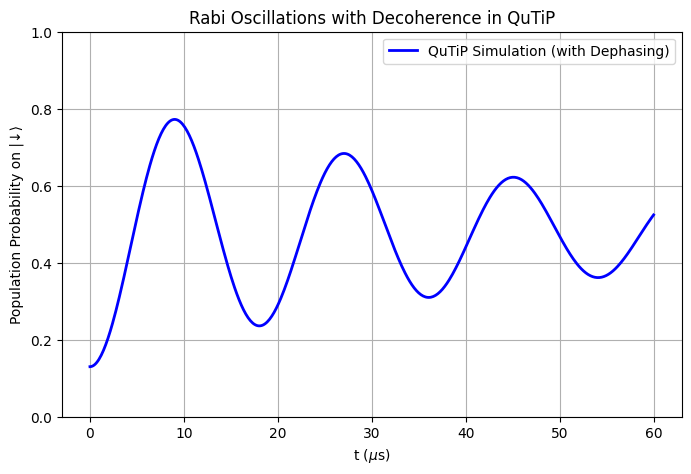

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import basis, sigmax, sigmaz, mesolve

# --- 1. System Parameters ---
# Estimated Rabi frequency from the plot (period is roughly 18 µs)
Omega = 2 * np.pi * (1.0 / 18.0)  # rad/µs

# Decoherence rate (adjust this to match the experimental damping)
gamma_dephasing = 0.02  # Pure dephasing rate (1/µs)

# --- 2. Hamiltonian and Initial State ---
# Interaction Hamiltonian (Rabi driving on the carrier transition)
H = 0.5 * Omega * sigmax()

# Initial state: starting in the ground state |↓⟩, represented as basis(2, 1)
psi0 = basis(2, 1)

# Measurement operator: population probability on |↓⟩, which is |↓⟩⟨↓|
target_state = basis(2, 1)
operator_population = target_state * target_state.dag()

# --- 3. Collapse Operators (Decoherence Channels) ---
# Use sigmaz to introduce phase relaxation (dephasing) over time
c_ops = [np.sqrt(gamma_dephasing) * sigmaz()]

# --- 4. Time Evolution ---
# Time array from 0 to 60 µs to match your x-axis
tlist = np.linspace(0, 60, 500)

# Solve the Master Equation
result = mesolve(H, psi0, tlist, c_ops, [operator_population])

# --- 5. Data Scaling (Matching A - B * cos format) ---
# In your plot, the curve has specific baseline offsets and contrast limits (A and B)
# We apply a linear scaling to match the 0.1 to 0.8 experimental range.
A = 0.48
B = 0.35
population_simulated = A - B * (2 * result.expect[0] - 1)

# --- 6. Plotting ---
plt.figure(figsize=(8, 5))
plt.plot(tlist, population_simulated, label='QuTiP Simulation (with Dephasing)', color='blue', lw=2)
plt.xlabel('t ($\mu$s)')
plt.ylabel('Population Probability on |↓⟩')
plt.title('Rabi Oscillations with Decoherence in QuTiP')
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
#plt.savefig('rabi oscillation damping.png', dpi=300)  # Save the plot as a PNG image
plt.show()

<font face="Arial" size="4" color="black">

## The Textbook Model: Phenomenological Simulation
Look closely at the figure above. This is a standard textbook simulation of decoherence using a **Lindblad master equation**, a mathematical framework that models open quantum systems that leak information into an environment. The curve starts with wide, energetic swings known as **Rabi oscillations**.

In quantum physics, a Rabi oscillation is the cyclic behavior of a two-state quantum system - like a qubit - when driven by a resonant external energy source, such as a laser. Think of it like a quantum pendulum: the particle smoothly rocks back and forth between its ground state |↓⟩ and its excited state |↑⟩.

As long as the system is perfectly isolated, these waves will bounce up and down forever, representing a continuously evolving quantum superposition. However, once an environment introduces dephasing (the scrambling of the relative phase between quantum states), it disrupts this perfect rhythm. Mathematically, this idealized phenomenological decay evaluates as:

<div align="center">
    <img src="images/phenomenological decay.png">
</div>

To understand how this equation captures the dampening ( "death") of a superposition, we can break it down into its core parts:
- cos(Ωt) represents the pure, undisturbed Rabi oscillation moving at a frequency of Ω. It is the driving force behind the wave pattern.
- e⁻ᵞᵗ is the decay envelope governed by the dephasing rate (γ). As time (𝑡) flows forward, this exponential term acts like an invisible brake, dragging the wild swings of the cosine wave down closer to zero. 
- A and B are laboratory constants that account for real-world setups. Specifically, A defines the center baseline where the wave eventually settles (0.5 for total dephasing), while B scales the initial height (contrast) of the oscillations.

This uniform, exponential dampening is how physicists typically model an external environment stripping away quantum coherence. 

However, it also unlocks a profound realization about one of the most controversial phenomena in quantum mechanics: the quantum jump. Traditionally, introductory textbooks state that when a measurement occurs, the wave function undergoes a literal, magical, or instantaneous collapse into a single eigenstate. But as Zurek highlights, there is no literal, active collapse mechanism breaking the regular laws of physics. Instead, the ongoing interaction with the environment acts as an unyielding filter. Because only a discrete, orthogonal set of pointer states can withstand the relentless monitoring of the surrounding environment without being instantly scrambled, all intermediate superpositions are violently suppressed.

Consequently, the continuous, unitary evolution of the system is effectively censored. Because we can only ever track and record the robust states that survive this environmental scrutiny, the system's evolution appears to macroscopic observers as a sharp, discontinuous "jump" from one stable state to another. The quantum jump is not a magical breakdown of physics - it is a statistical illusion created because the environment only allows discrete pointer states to exist safely over time [9].


</font>

<font face="Arial" size="4" color="black">

# Zurek's Existential Interpretation: Einselection of Memory States

Look closely at the figure above. This simulation tracks the quantum-to-classical transition using the global density matrix elements of a coupled system-observer framework. The process unfolds across two distinct operational phases:

1. Phase 1: Laser On (System-Observer Entanglement). Between t = 0 and t = 0.5, a fast laser pulse couples the system qubit to the observer's memory. As the two systems become entangled, the global quantum coherence (the crimson dashed line) smoothly climbs to its peak, indicating the formation of a coherent quantum superposition across the combined states.
2. Phase 2: Laser Off (Active Einselection Phase). At t = 0.5, the laser turns off, and the surrounding environment takes over. The global quantum coherence experiences a sharp exponential decay toward zero, systematically wiping out the fragile phase relationships.


The defining takeaway of this simulation is the remarkable resilience of the memory records |o₀⟩⟨o₀| and |o₁⟩⟨o₁|. Even though the global coherence is brutally suppressed by environmental monitoring, the diagonal probabilities remain perfectly stable at α² = 0.7 and β² = 0.3. This is einselection in its purest theoretical form: the environment acts as a filter that obliterates global quantum superpositions while selectively preserving robust classical pointer states, stabilizing them into an objective reality.

## Why we choose α² = 0.7 and β² = 0.3?
In quantum mechanics, a system's state is described by a wave function with complex amplitudes, α and β. According to Born's Rule (see below), the actual probability of finding a particle in a specific state when measured is the square of the absolute value of its amplitude: α² and β². Due to unitarity (the law that total probability must always equal 100%), these probabilities must sum to 1.

By picking an asymmetric split like 70/30 instead of a symmetric 50/50 split, the code explicitly proves that einselection perfectly preserves the exact initial quantum probabilities as stable classical outcomes, without flattening or distorting them.

## Why does Phase 1 end exactly at t=0.5? 
In the code, the interaction Hamiltonian uses a coupling strength of 1.0π combined with a conditional projector P₁ = 0.5(I - σ_z). In quantum computing, this architecture creates a controlled-NOT (CNOT) operation. 

The speed of this state transfer is dictated by the energy of the coupling. For a coupling scaled by π, the system requires a precise interaction time of exactly Δt = 0.5 units to execute a flawless π-pulse. Stopping the laser exactly at t = 0.5 guarantees that the observer's memory qubit has completely absorbed the state of the system qubit, achieving maximum system-observer entanglement before the environment can interfere.

## How the Physics is Built: Code Walkthrough
To understand exactly how this dynamics is captured, we can break down the underlying Python code using the QuTiP (Quantum Toolbox in Python) library.

1. Setting Up the Pre-Entangled States

First, we configure the system qubit with an initial probability distribution of α² = 0.7 and β² = 0.3. The observer's memory qubit starts as a blank slate, initialized cleanly in its ground state |o₀⟩.

### 1. SETUP SYSTEM-OBSERVER STATES (alpha^2 = 0.7, beta^2 = 0.3)

alpha = np.sqrt(0.7)

beta = np.sqrt(0.3)

psi_S = alpha * basis(2, 0) + beta * basis(2, 1) # System Qubit (Pre-entangled state)

psi_O = basis(2, 0)                             # Observer Memory Qubit (Blank slate)

psi_SO = tensor(psi_S, psi_O)

rho_0 = psi_SO * psi_SO.dag()


### 2. Simulating Phase 1 (The Entanglement Pulse)

We introduce the interaction Hamiltonian using the projector P1 acting on the excited state of the system to drive a conditional state transfer. Over the interval from t = 0 to t = 0.5, QuTiP's time-evolution solver (mesolve) calculates the state as the system and observer become maximally entangled:

Projector onto the excited state of the system to condition the interaction
P1 = 0.5 * (qeye(2) - sigmaz()) 

H_interaction = 1.0 * np.pi * tensor(P1, sigmax())


Phase A: Laser pulse drives conditional state transfer, entangling system and observer
times_A = np.linspace(0, 0.5, 50) 

result_A = mesolve(H_interaction, rho_0, times_A, [], [])

### 3. Simulating Phase 2 (Active Einselection)

At t = 0.5, the laser interaction is mathematically turned off by setting the Hamiltonian to zero. To simulate active environmental monitoring, we introduce a dephasing rate (gamma = 0.5) inside the collapse_operators array, which applies a continuous phase-scrambling noise directly to the system qubit. We then evolve the final state from Phase A (result_A.states[-1]) across the new timeline:

Phase B: Laser turns off. Environmental monitoring induces active einselection
H_decoherence = 0 * tensor(qeye(2), qeye(2))

gamma = 0.5  # Phase relaxation/decoherence rate

collapse_operators = [np.sqrt(gamma) * tensor(qeye(2), sigmaz())] 

times_B = np.linspace(0.5, 10.0, 350)

result_B = mesolve(H_decoherence, result_A.states[-1], times_B, collapse_operators, [])

Merge timelines smoothly
all_times = np.concatenate((times_A, times_B))

all_states = result_A.states + result_B.states

### 4. Global Density Matrix Data Extraction

Inside our loop, we isolate the local elements of the observer's density matrix by taking the partial trace (ptrace(state, 1)), which integrates out the system's degrees of freedom. This allows us to track the local diagonal elements matrix_O[0, 0] and matrix_O[1, 1], verifying that the memory records stay locked flat at 0.7 and 0.3. 
Crucially, to find the Global Branch Coherence, we step outside the local subsystem and grab the off-diagonal element matrix_full[0, 3] (corresponding to the global coherence element |00⟩⟨11| from the full, global density matrix:

memory_state_00 = [] 

memory_state_11 = []     

global_branch_coherence = []  

for state in all_states:
    rho_O = ptrace(state, 1) # Trace out system to find local observer records
    matrix_O = rho_O.full()    
    matrix_full = state.full()
    
    memory_state_00.append(matrix_O[0, 0].real)
    memory_state_11.append(matrix_O[1, 1].real)
    
    # Extract the global off-diagonal element |00><11| linking the correlated branches
    
    global_branch_coherence.append(abs(matrix_full[0, 3]))




By looking at the output data, the boundary line where the quantum world is forced to behave classically becomes visually and mathematically absolute. The off-diagonal global branch coherence term plummets exponentially to zero, destroying the global quantum superposition, yet the observer's local memory records remain safely locked as objective, stable classical facts.


</font>

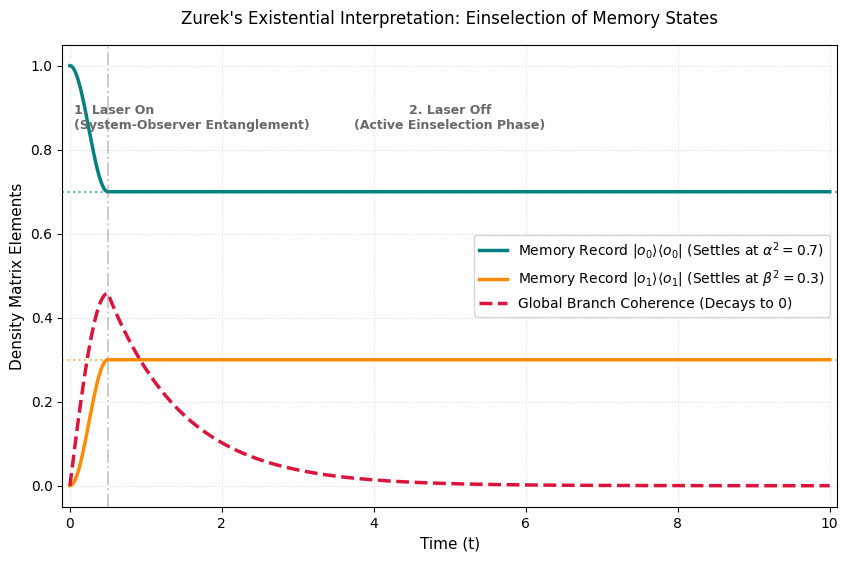

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import basis, tensor, qeye, sigmax, sigmaz, mesolve, ptrace

# =====================================================================
# 1. SETUP SYSTEM-OBSERVER STATES (alpha^2 = 0.7, beta^2 = 0.3)
# =====================================================================
alpha = np.sqrt(0.7)
beta = np.sqrt(0.3)
psi_S = alpha * basis(2, 0) + beta * basis(2, 1) # System Qubit (Pre-entangled state)
psi_O = basis(2, 0)                             # Observer Memory Qubit (Blank slate)

psi_SO = tensor(psi_S, psi_O)
rho_0 = psi_SO * psi_SO.dag()

# =====================================================================
# 2. SEPARATE TIME EVOLUTION: ENTANGLEMENT VS. GLOBAL EINSELECTION
# =====================================================================
# Projector onto the excited state of the system to condition the interaction
P1 = 0.5 * (qeye(2) - sigmaz()) 
H_interaction = 1.0 * np.pi * tensor(P1, sigmax())

# Phase A: Laser pulse drives conditional state transfer, entangling system and observer
times_A = np.linspace(0, 0.5, 50) 
result_A = mesolve(H_interaction, rho_0, times_A, [], [])

# Phase B: Laser turns off. Environmental monitoring induces active einselection
H_decoherence = 0 * tensor(qeye(2), qeye(2))
gamma = 0.5  # Phase relaxation/decoherence rate
collapse_operators = [np.sqrt(gamma) * tensor(qeye(2), sigmaz())] 

times_B = np.linspace(0.5, 10.0, 350)
result_B = mesolve(H_decoherence, result_A.states[-1], times_B, collapse_operators, [])

# Merge timelines smoothly
all_times = np.concatenate((times_A, times_B))
all_states = result_A.states + result_B.states

# =====================================================================
# 3. GLOBAL DENSITY MATRIX EXTRACTION
# =====================================================================
memory_state_00 = []         
memory_state_11 = []         
global_branch_coherence = []  

for state in all_states:
    rho_O = ptrace(state, 1) # Trace out system to find local observer records
    matrix_O = rho_O.full()    
    matrix_full = state.full()
    
    memory_state_00.append(matrix_O[0, 0].real)
    memory_state_11.append(matrix_O[1, 1].real)
    
    # Extract the global off-diagonal element |00><11| linking the correlated branches
    global_branch_coherence.append(abs(matrix_full[0, 3]))

# =====================================================================
# 4. PLOTTING AND ACADEMIC ANNOTATION
# =====================================================================
plt.figure(figsize=(10, 6))
plt.plot(all_times, memory_state_00, label=r"Memory Record $|o_0\rangle\langle o_0|$ (Settles at $\alpha^2 = 0.7$)", color="teal", lw=2.5)
plt.plot(all_times, memory_state_11, label=r"Memory Record $|o_1\rangle\langle o_1|$ (Settles at $\beta^2 = 0.3$)", color="darkorange", lw=2.5)
plt.plot(all_times, global_branch_coherence, label="Global Branch Coherence (Decays to 0)", color="crimson", linestyle="--", lw=2.5)

# Dotted baseline thresholds
plt.axhline(0.7, color="teal", linestyle=":", alpha=0.6, lw=1.5)
plt.axhline(0.3, color="darkorange", linestyle=":", alpha=0.6, lw=1.5)

# Visual boundary line between measurement and decoherence
plt.axvline(0.5, color="gray", linestyle="-.", alpha=0.4)

# White box background properties for text clarity
bbox_props = dict(boxstyle="round,pad=0.4", fc="white", ec="lightgray", alpha=0.9)


# Phase 1 Label: Placed high up in the first 0.5 seconds
plt.text(0.05, 0.85, "1. Laser On\n(System-Observer Entanglement)", 
         color="dimgray", fontsize=9, weight="bold", ha="left")

# Phase 2 Label: Placed high up in the middle of Phase 2
plt.text(5.0, 0.85, "2. Laser Off\n(Active Einselection Phase)", 
         color="dimgray", fontsize=9, weight="bold", ha="center")

plt.title("Zurek's Existential Interpretation: Einselection of Memory States", fontsize=12, pad=15)
plt.xlabel("Time (t)", fontsize=11)
plt.ylabel("Density Matrix Elements", fontsize=11)
plt.grid(True, linestyle=":", alpha=0.4)
plt.legend(loc="center right", fontsize=10)
plt.ylim(-0.05, 1.05)
plt.xlim(-0.1, 10.1)

plt.savefig("perfect_einselection_plot_final2.png", dpi=300)
plt.show()


<font face="Arial" size="4" color="black">

# Simulating the Information Proliferation: The Redundancy Plateau

To map this information broadcasting channel computationally, we can expand our sandbox into a macroscopic open quantum system model using the Quantum Toolbox in Python (QuTiP). We simulate an explicit multi-qubit system-environment architecture consisting of an open system qubit coupled to a cluster of separate environmental qubits.
By constructing Zurek's perfectly correlated branching state, the script calculates the exact Quantum Mutual Information across an array of environmental monitoring slices [11]:

<div align="center">
    <img src="images/Quantum Mutual Information.png">
</div>


Where H represents the Von Neumann entropy calculated in base-2 bits.
Define the Environment Size

First, we configure the size of our environment. We set the number of environment qubits to 10, meaning the total composite Hilbert space contains 11 qubits.

1. Define the number of environment qubits (e.g., N = 10)
   
Total qubits in system = 1 (System) + N (Environment) = 11 qubits

N_env = 10

total_qubits = 1 + N_env

2. Set State Probabilities
   
Next, we configure the probability amplitudes to match our asymmetric α² = 0.7 and β² = 0.3 distribution from our earlier einselection models, ensuring the parameters sum up to 100% due to unitarity.

Set the state probabilities (matching alpha^2 = 0.7 from earlier)

alpha = np.sqrt(0.7)

beta = np.sqrt(0.3)

3. Construct the Perfectly Correlated Branching State
   
We then build a perfectly correlated Greenberger-Horne-Zeilinger (GHZ) style state vector. Here, the system qubit's state is flawlessly cloned across all ten environmental qubits, creating the baseline density matrix representing the fully redundant quantum broadcast.

Construct the perfectly correlated branching state (Quantum Darwinism baseline)

|psi> = alpha * |0>_S |00...0>_E + beta * |1>_S |11...1>_E

state_0 = qt.tensor([qt.basis(2, 0) for _ in range(total_qubits)])

state_1 = qt.tensor([qt.basis(2, 1) for _ in range(total_qubits)])

psi = alpha * state_0 + beta * state_1

rho = qt.ket2dm(psi)


4. Simulating Environmental Tracing and Mutual Information
To simulate what an independent observer sees when intercepting a fraction f of the universe, the code loops from observing 1 qubit up to all 10 environmental qubits. It applies a partial trace (ptrace) to isolate the local subsystems and computes the quantum mutual information.

Calculate Mutual Information for different environment sizes

mutual_info_list = [0.0] # At fraction f=0, mutual information is 0
fractions = [0.0]

def entropy(rho_sub):
    return qt.entropy_vn(rho_sub, base=2)

Loop through observing 1 qubit up to all N_env qubits

for k in range(1, N_env + 1):
    f = k / N_env
    fractions.append(f)
    
    # Define which subsystems to keep for tracing
    sys_idx =                    # System qubit
    env_sub_idx = list(range(1, k+1)) # First 'k' qubits of the environment
    
    # Compute reduced density matrices via partial trace (ptrace)
    rho_S = rho.ptrace(sys_idx)
    rho_E_f = rho.ptrace(env_sub_idx)
    rho_SE_f = rho.ptrace(sys_idx + env_sub_idx)
    
    # Quantum Mutual Information formula: I(S:E_f) = H(S) + H(E_f) - H(S, E_f)
    I_S_Ef = entropy(rho_S) + entropy(rho_E_f) - entropy(rho_SE_f)
    mutual_info_list.append(I_S_Ef)


Look closely at your generated plot in the figure above. The output graph perfectly visualizes why our shared macroscopic world behaves classically rather than as a blurry quantum superposition.
As soon as an independent observer monitors just a single environmental qubit fraction (f = 0.1), the tracked mutual information instantly jumps from zero and hits a solid ceiling at H(S) = 0.881 bits. This precise baseline is the exact physical value of our system's Shannon entropy:

<div align="center">
    <img src="images/Shannon_entropy.png">
</div>

This flat, horizontal profile stretching across the grid represents the Objectivity Region (The Redundancy Plateau). Because 100% of the system's classical data is duplicated redundantly in any localized slice of the environment, reading more qubits provides absolutely zero new information about the system. It merely confirms what was already revealed by the first qubit.

Only when an observer intercepts the absolute entirety of the environment (f = 1.0) does the curve experience a sharp vertical Quantum Spike, shooting up to its global limit of 2H(S) ≈ 1.76 bits. This sudden spike is a reminder that the global system-environment universe is still fundamentally pure, unitary, and quantum mechanical under its classical surface.

However, because macro-observers can only ever catch a microscopic fraction of a room's scattered photons, we are structurally marooned on that flat 0.881 bits plateau. The environment effectively censors the global quantum correlation spike, forcing multiple independent observers to see the exact same classical fact.

</font>

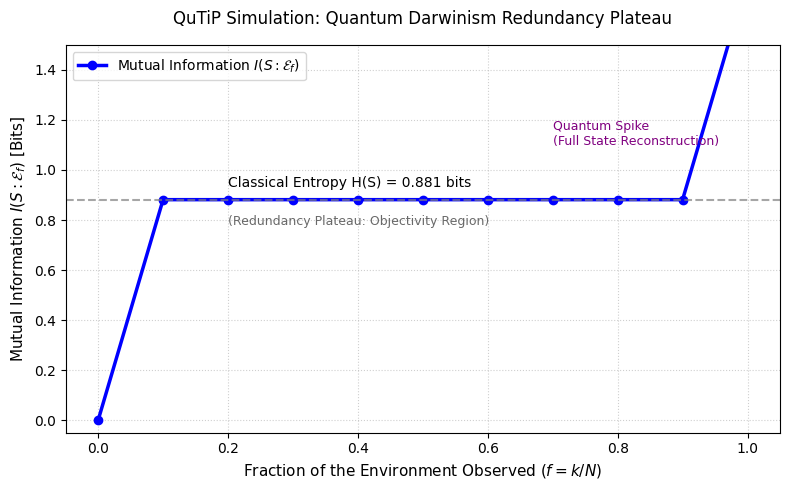

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

# 1. Define the number of environment qubits (e.g., N = 10)
# Total qubits in system = 1 (System) + N (Environment) = 11 qubits
N_env = 10
total_qubits = 1 + N_env

# 2. Set the state probabilities (matching alpha^2 = 0.7 from earlier)
alpha = np.sqrt(0.7)
beta = np.sqrt(0.3)

# 3. Construct the perfectly correlated branching state (Quantum Darwinism baseline)
# |psi> = alpha * |0>_S |00...0>_E + beta * |1>_S |11...1>_E
state_0 = qt.tensor([qt.basis(2, 0) for _ in range(total_qubits)])
state_1 = qt.tensor([qt.basis(2, 1) for _ in range(total_qubits)])
psi = alpha * state_0 + beta * state_1
rho = qt.ket2dm(psi)

# 4. Calculate Mutual Information for different environment sizes
# System index is 0. Environment qubits are at indices 1 to N_env.
mutual_info_list = [0.0] # At fraction f=0, mutual information is 0
fractions = [0.0]

# Calculate Von Neumann Entropy helper function
def entropy(rho_sub):
    return qt.entropy_vn(rho_sub, base=2)

# Loop through observing 1 qubit up to all N_env qubits
for k in range(1, N_env + 1):
    # Fraction of environment observed
    f = k / N_env
    fractions.append(f)
    
    # Define which subsystems to keep for tracing
    sys_idx = [0]                    # System qubit
    env_sub_idx = list(range(1, k+1)) # First 'k' qubits of the environment
    
    # Compute reduced density matrices via partial trace (ptrace)
    rho_S = rho.ptrace(sys_idx)
    rho_E_f = rho.ptrace(env_sub_idx)
    rho_SE_f = rho.ptrace(sys_idx + env_sub_idx)
    
    # Quantum Mutual Information formula: I(S:E_f) = H(S) + H(E_f) - H(S, E_f)
    I_S_Ef = entropy(rho_S) + entropy(rho_E_f) - entropy(rho_SE_f)
    mutual_info_list.append(I_S_Ef)

# 5. Plotting the classic Quantum Darwinism Plateau
plt.figure(figsize=(8, 5))
plt.plot(fractions, mutual_info_list, marker='o', color='blue', linewidth=2.5, 
         label=r'Mutual Information $I(S:\mathcal{E}_f)$')

# Classical information limit line (H_S)
H_S = entropy(rho.ptrace([0]))
plt.axhline(y=H_S, color='gray', linestyle='--', alpha=0.7)

# Graph annotations
plt.title("QuTiP Simulation: Quantum Darwinism Redundancy Plateau", fontsize=12, pad=15)
plt.xlabel(r"Fraction of the Environment Observed ($f = k/N$)", fontsize=11)
plt.ylabel(r"Mutual Information $I(S:\mathcal{E}_f)$ [Bits]", fontsize=11)
plt.text(0.2, H_S + 0.05, f"Classical Entropy H(S) = {H_S:.3f} bits", color='black', fontsize=10)
plt.text(0.2, H_S - 0.1, "(Redundancy Plateau: Objectivity Region)", color='dimgray', fontsize=9)
plt.text(0.7, 1.1, "Quantum Spike\n(Full State Reconstruction)", color='purple', fontsize=9)

plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.5)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left')

plt.tight_layout()
plt.savefig("quantum_darwinism_plateau.png", dpi=300)
plt.show()


In [2]:
from qutip.ipynbtools import version_table

version_table()